# Sirroz bemorlarining kelajagini bashorat qilish — ma'lumotlar tahlili loyihasi

*Mohirdev kursi uchun tayyorlangan amaliy loyiha*

---

Tasavvur qiling: shifoxonada 15 ming nafar jigar sirrozi bilan og'rigan bemorning
tibbiy tarixi bor. Har bir bemor haqida yoshi, jinsi, qabul qilgan dori turi va
o'nlab qon tahlili natijalari yozilgan. Bizning vazifamiz — shu ma'lumotlarga
qarab, bemorning kelajagi haqida bashorat qilish: u tuzalib ketadimi (`C`),
jigar transplantatsiyasi kerak bo'ladimi (`CL`), yoki afsuski vafot etadimi (`D`)?

Bu — real ma'lumotlarga asoslangan **ko'p sinfli klassifikatsiya** masalasi
(Kaggle Playground Series S3E26 musobaqasidan olingan, asl manba — Mayo Clinic
shifoxonasining PBC (birlamchi biliar sirroz) tadqiqoti). Biz bu daftarda
butun yo'lni birga bosib o'tamiz: xom ma'lumotni ochishdan tortib, ishlaydigan
modelgacha. Har bir qadamda **nima qilyapmiz** va, eng muhimi, **nega aynan
shunday qilyapmiz** degan savolga javob beramiz.

**Model sifat mezoni — log loss.** Bu shunchaki "to'g'ri/noto'g'ri topdimi"
emas — model qanchalik **ishonchli** to'g'ri javob berganini o'lchaydi. Agar
bemor aslida `D` bo'lsa-yu, model "90% ehtimol bilan `C`" desa, bu "55% ehtimol
bilan `D`" deb noaniq javob berishdan ham qattiqroq jazolanadi. Shuning uchun
bizga faqat to'g'ri bashorat emas, **to'g'ri kalibratsiyalangan ehtimollik** kerak.

In [1]:
import warnings
from pathlib import Path

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.dummy import DummyClassifier
from sklearn.metrics import log_loss
from sklearn.model_selection import StratifiedKFold

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
np.random.seed(42)

DATA_DIR = Path("../data/raw")
SEED = 42
TARGET = "Status"
CLASSES = ["C", "CL", "D"]

print("Kutubxonalar yuklandi. Boshlaymiz!")

Kutubxonalar yuklandi. Boshlaymiz!


## 1-qism. Ma'lumotlar bilan tanishuv

Har qanday ma'lumotlar tahlili loyihasi bitta oddiy qoidadan boshlanadi:
**modelni o'qitishga shoshilmang, avval ma'lumotni tushuning.** Kelib chiqishi,
hajmi, ustunlari — bularning barchasi keyingi har bir qarorimizga ta'sir qiladi.

In [2]:
train = pd.read_csv(DATA_DIR / "train.csv").set_index("id")
test = pd.read_csv(DATA_DIR / "test.csv").set_index("id")

print(f"O'quv to'plami (train): {train.shape[0]:,} bemor, {train.shape[1]} ustun")
print(f"Test to'plami: {test.shape[0]:,} bemor, {test.shape[1]} ustun")
print("\nUstunlar:")
print(list(train.columns))
train.head(3)

O'quv to'plami (train): 15,000 bemor, 19 ustun
Test to'plami: 10,000 bemor, 18 ustun

Ustunlar:
['N_Days', 'Drug', 'Age', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin', 'Stage', 'Status']


,N_Days,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage,Status
id,,,,,,,,,,,,,,,,,,,
0,2178.0,D-penicillamine,16374.0,F,N,N,N,N,0.5,263.0,3.2,43.0,1110.0,106.95,67.0,430.0,9.6,3.0,C
1,2644.0,D-penicillamine,17774.0,F,N,N,N,N,0.8,280.0,3.6,22.0,678.0,62.00,80.0,427.0,13.0,3.0,C
2,3069.0,Placebo,17844.0,F,N,N,N,N,1.1,408.0,4.4,54.0,2108.0,142.60,137.0,203.0,10.6,3.0,C


Ustunlarni ikki guruhga bo'lish mumkin:

- **Raqamli klinik ko'rsatkichlar:** `Bilirubin`, `Albumin`, `Cholesterol`,
  `Copper`, `Alk_Phos`, `SGOT`, `Tryglicerides`, `Platelets`, `Prothrombin` —
  bularning barchasi qon tahlili natijalari. `N_Days` — bemor tadqiqotda
  kuzatilgan kunlar soni, `Age` — yosh (kunlarda hisoblangan).
- **Kategorial (tavsifiy) ustunlar:** `Drug` (qabul qilgan dori), `Sex`,
  `Ascites`, `Hepatomegaly`, `Spiders`, `Edema` (klinik belgilar — bor/yo'q),
  `Stage` (kasallik bosqichi, 1 dan 4 gacha).

Va nihoyat, biz bashorat qilishimiz kerak bo'lgan `Status` — bemorning yakuniy
holati. Keling, unga yaqinroq qaraymiz.

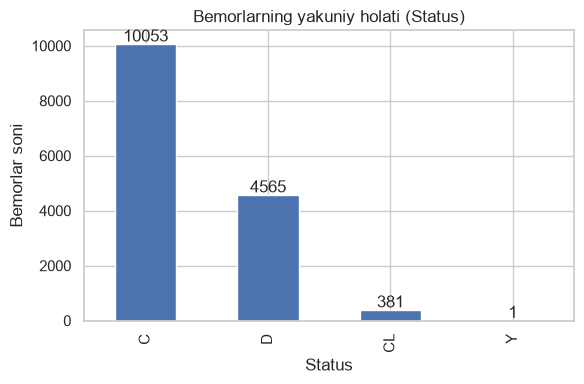

Status
C     10053
D      4565
CL      381
Y         1
Name: count, dtype: int64


In [3]:
counts = train[TARGET].value_counts()
fig, ax = plt.subplots(figsize=(6, 4))
counts.reindex(["C", "D", "CL", *[c for c in counts.index if c not in CLASSES]]).plot(kind="bar", ax=ax)
ax.set_title("Bemorlarning yakuniy holati (Status)")
ax.set_ylabel("Bemorlar soni")
for i, v in enumerate(counts.reindex(["C", "D", "CL", *[c for c in counts.index if c not in CLASSES]])):
    ax.text(i, v + 100, str(int(v)), ha="center")
plt.tight_layout()
plt.show()

print(counts)

**Bu yerda ikkita muhim narsa darhol ko'zga tashlanadi:**

1. **Sinflar teng emas** ("disbalans"). Bemorlarning ~67%i `C`, ~30%i `D`, va
   atigi ~2.5%i `CL`. Bu shuni anglatadiki, agar model "har doim `C` deb
   taxmin qil" desak ham, u 67% hollarda to'g'ri chiqadi! Shuning uchun oddiy
   "aniqlik" (accuracy) bu masalada chalg'ituvchi mezon — biz log loss'ga
   tayanamiz, va `CL` kabi kam uchraydigan sinfga alohida e'tibor beramiz.
2. Grafikda `C`/`CL`/`D` dan tashqari yana bir ustunchа bor bo'lishi mumkin —
   buni pastda tekshiramiz.

In [4]:
unexpected = train[~train[TARGET].isin(CLASSES)]
print(f"'{'/'.join(CLASSES)}' dan boshqa qiymatli qatorlar: {len(unexpected)} ta")
unexpected

'C/CL/D' dan boshqa qiymatli qatorlar: 1 ta


,N_Days,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage,Status
id,,,,,,,,,,,,,,,,,,,
13789,4127.0,Placebo,20555.0,F,Y,Y,Y,Y,0.6,267.0,2.75,11.0,1273.0,72.85,49.0,156.0,13.0,4.0,Y


Xato topdik! 15 000 qatorning bittasida `Status` ustunida `"Y"` degan, hech
qanday ma'noga ega bo'lmagan qiymat bor. Bu — real hayotdagi ma'lumotlarning
odatiy holati: hech qanday dataset 100% mukammal bo'lmaydi, va tajribali
tahlilchi buni ko'r-ko'rona qabul qilmaydi, balki qidirib topadi. Bitta qator
bo'lgani uchun uni oddiygina o'chirib tashlaymiz (buni keyinroq qilamiz).

## 2-qism. Ma'lumot to'liqmi? — Null qiymatlar sirini ochamiz

Endi eng qiziqarli va ko'pincha e'tiborsiz qoldiriladigan qismga o'tamiz:
bo'sh (yo'q) qiymatlar tahliliga. Ko'plab boshlang'ich tahlilchilar bu yerda
shunchaki "o'rtacha bilan to'ldiraman-qo'yaman" deb o'tib ketishadi. Biz esa
avval **nega** bo'sh ekanini tushunishga harakat qilamiz — chunki sabab
yechimni belgilaydi.

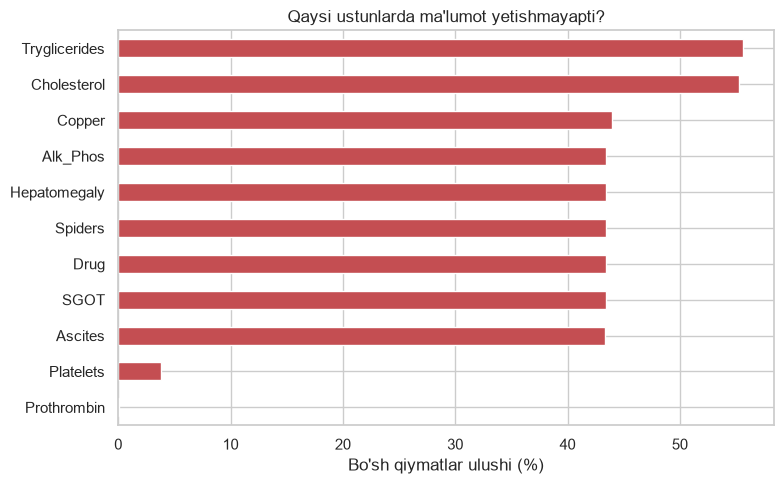

In [5]:
null_pct = train.isnull().mean().mul(100).round(1).sort_values(ascending=False)
null_pct = null_pct[null_pct > 0]

fig, ax = plt.subplots(figsize=(8, 5))
null_pct.plot(kind="barh", ax=ax, color="#C44E52")
ax.set_xlabel("Bo'sh qiymatlar ulushi (%)")
ax.set_title("Qaysi ustunlarda ma'lumot yetishmayapti?")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

Ko'ryapsizmi — bu tasodifiy kichik "teshiklar" emas! Ustunlarning yarmidan
ko'prog'ida (`Drug`, `Ascites`, `Copper`, `Alk_Phos`, `SGOT`...) ma'lumotning
**~43-55%i** yo'q. Bu darajadagi yo'qotish tasodifiy bo'lishi mumkin emas.
Keling, buni isbotlab ko'ramiz: agar bitta ustun bo'sh bo'lsa, boshqalari ham
aynan o'sha qatorlarda bo'shmi?

In [6]:
check_cols = ["Drug", "Ascites", "Hepatomegaly", "Spiders", "Alk_Phos", "SGOT", "Copper"]
null_together = train[check_cols].isnull().all(axis=1).sum()
null_none = (~train[check_cols].isnull().any(axis=1)).sum()

print(f"Shu {len(check_cols)} ta ustun BIR VAQTDA bo'sh bo'lgan bemorlar: {null_together:,} ta")
print(f"Shu {len(check_cols)} ta ustun BARCHASI to'liq bo'lgan bemorlar: {null_none:,} ta")
print(f"Jami bemorlar: {len(train):,}")

Shu 7 ta ustun BIR VAQTDA bo'sh bo'lgan bemorlar: 6,465 ta
Shu 7 ta ustun BARCHASI to'liq bo'lgan bemorlar: 8,389 ta
Jami bemorlar: 15,000


**Mana javob!** Bemorlarning taxminan yarmida bu ustunlarning HAMMASI birga
bo'sh, qolgan yarmida esa HAMMASI to'liq. Bu tasodif emas — bu **ma'lumot
qanday yig'ilganining izi**. Asl tadqiqotda ikki guruh bemor bo'lgan: birinchi
guruh to'liq klinik tekshiruvdan (dori, qon tahlillari) o'tgan, ikkinchi guruh
esa faqat asosiy kuzatuvda qatnashgan, chuqur tekshiruv qilinmagan.

**Nega bu muhim?** Chunki bu bizga to'ldirish strategiyasini belgilaydi:

- ❌ **Noto'g'ri yo'l:** bo'sh joylarni o'rtacha (mean/median) qiymat bilan
  to'ldirish. Bu yarim dataset uchun **soxta** ma'lumot yaratadi va model
  chalg'ib qoladi.
- ✅ **To'g'ri yo'l:** bo'sh joylarni bo'sh qoldirish. Biz ishlatadigan
  LightGBM kabi daraxt-asosidagi modellar bo'sh qiymatlarni **o'zi** aqlli
  tarzda hisobga oladi ("agar bu ustun bo'sh bo'lsa, bemorni shu tomonga
  yo'nalt" degan qoidani o'zi o'rganib oladi) — bu haqiqiy signalni saqlaydi.

## 3-qism. Raqamli ustunlar qanday taqsimlangan?

Statistikada mashhur bir hazil bor: "o'rtacha uy xo'jaligida 2.3 bola bor"
degan gap hech kimga taalluqli emas. Xuddi shunday, ma'lumotning **shakli**ni
(taqsimotini) ko'rmasdan turib xulosa chiqarish xato. Keling, klinik
ko'rsatkichlarga qarab chiqamiz.

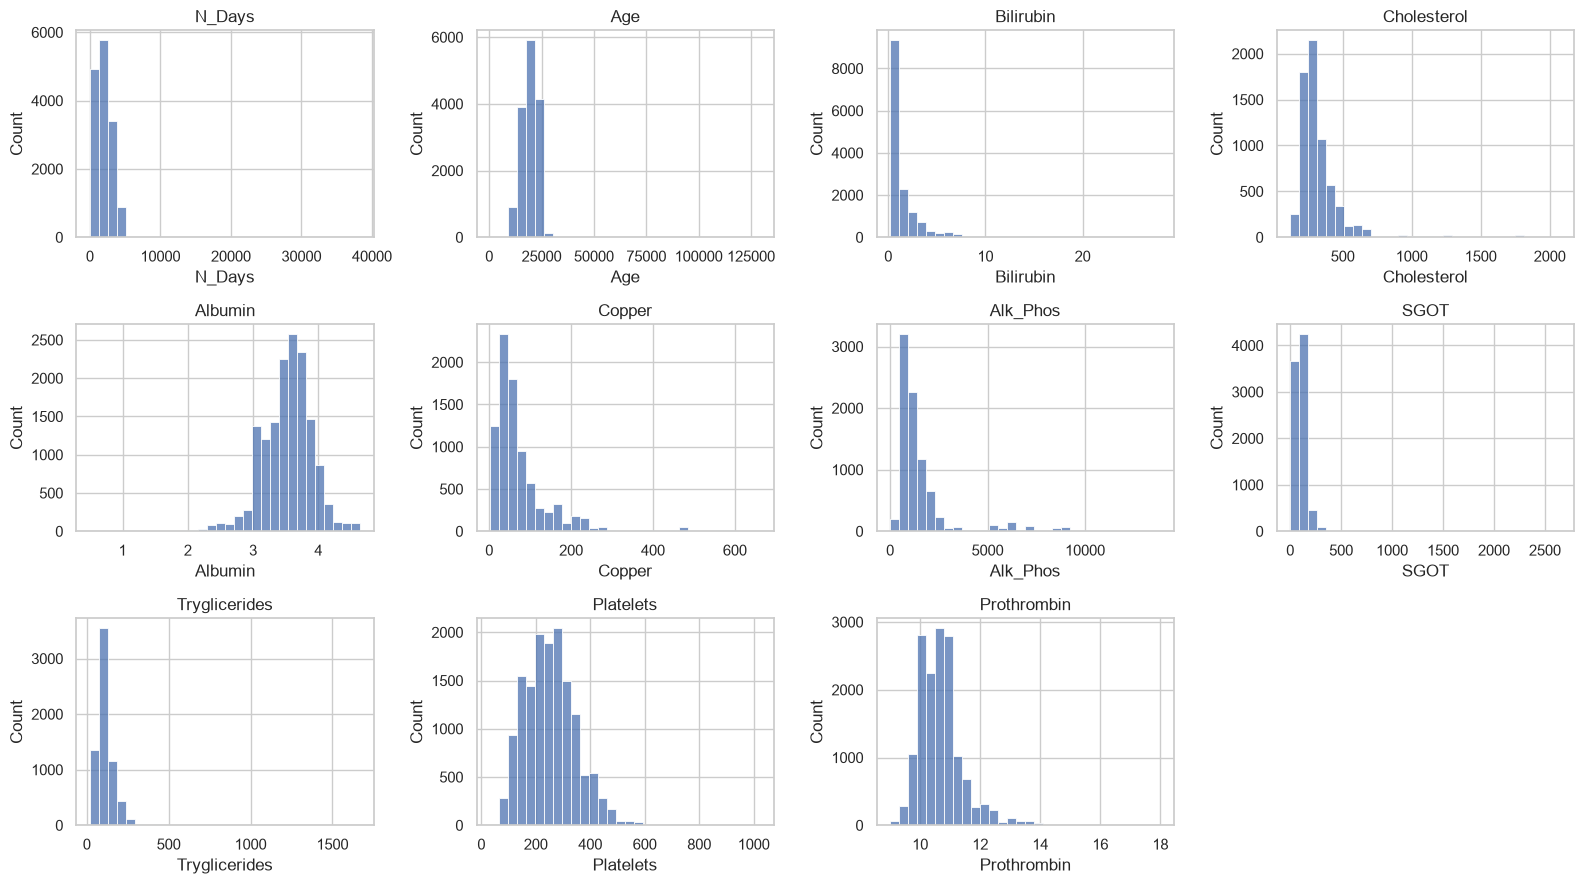

Qiyalik (skewness) — 0 ga yaqin bo'lsa simmetrik, katta bo'lsa 'o'ngga cho'zilgan':
SGOT             11.86
N_Days            6.25
Tryglicerides     5.32
Cholesterol       4.33
Bilirubin         4.13
Alk_Phos          3.31
Copper            3.03
Age               1.88
Prothrombin       1.41
Platelets         0.63
Albumin          -0.38
dtype: float64


In [7]:
numeric_cols = ["N_Days", "Age", "Bilirubin", "Cholesterol", "Albumin", "Copper",
                "Alk_Phos", "SGOT", "Tryglicerides", "Platelets", "Prothrombin"]

fig, axes = plt.subplots(3, 4, figsize=(16, 9))
for ax, col in zip(axes.flat, numeric_cols):
    sns.histplot(train[col].dropna(), bins=30, ax=ax, color="#4C72B0")
    ax.set_title(f"{col}")
for ax in axes.flat[len(numeric_cols):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

print("Qiyalik (skewness) — 0 ga yaqin bo'lsa simmetrik, katta bo'lsa 'o'ngga cho'zilgan':")
print(train[numeric_cols].skew().sort_values(ascending=False).round(2))

Diagrammalarga qarang — ko'pchiligi (`SGOT`, `Bilirubin`, `Alk_Phos`, `Copper`)
"o'ngga cho'zilgan": aksariyat bemorlarning qiymati past, lekin ozgina
bemorlarda **juda** yuqori (masalan `Alk_Phos` uchun ba'zi bemorlarda
13,000+ ga yetadi, o'rtacha esa atigi ~1,600). Bu ajablanarli emas — og'ir
kasal bemorlarda ko'rsatkichlar keskin ko'tariladi.

*(Qiziq fakt: keyinroq biz bu qiyalikni "tekislash" uchun logaritmik
transformatsiya (`log1p`) sinab ko'ramiz — lekin natija hammani hayratda
qoldiradi, buni 6-qismda ko'rasiz!)*

## 4-qism. Ma'lumotni tozalash

Endi tushunganlarimizga asoslanib, ma'lumotni modelga tayyorlaymiz:

1. 1-qismda topgan anomal (`"Y"`) qatorni olib tashlaymiz.
2. `Status`ni matndan raqamga o'giramiz — kompyuter "tuzalgan"/"vafot etgan"
   so'zlarini emas, raqamlarni tushunadi: `C→0, CL→1, D→2`.

In [8]:
n_before = len(train)
train = train[train[TARGET].isin(CLASSES)].copy()
print(f"Tashlab yuborildi: {n_before - len(train)} ta anomal qator")

status_to_label = {status: i for i, status in enumerate(CLASSES)}
label_to_status = {i: status for status, i in status_to_label.items()}
train[TARGET] = train[TARGET].map(status_to_label).astype("int8")

print("Tayyor. Endi Status: 0=C, 1=CL, 2=D")
train[TARGET].value_counts().sort_index()

Tashlab yuborildi: 1 ta anomal qator
Tayyor. Endi Status: 0=C, 1=CL, 2=D


Status
0    10053
1      381
2     4565
Name: count, dtype: int64

## 5-qism. Bonus ma'lumot: asl tadqiqotni qo'shib ko'ramiz

Bu musobaqaning 15,000 qatorlik dataseti sun'iy (statistik usullar bilan
"kengaytirilgan") ma'lumot — asli esa Mayo Clinic'ning haqiqiy tadqiqotida
atigi **418 nafar** bemor bo'lgan. Qiziq savol: shu 418 ta "haqiqiy" bemorni
qo'shimcha o'quv ma'lumoti sifatida qo'shsak, model yaxshilanadimi?

**Bu yerda muhim bir tuzoq bor:** bu 418 qatorni hech qachon **tekshirish**
(validatsiya) uchun ishlatmasligimiz kerak — faqat **o'qitish** uchun. Aks
holda modelimizning haqiqiy sifatini noto'g'ri baholab qo'yamiz ("o'zini o'zi
tekshirish" xatosi). Buni qanday amalga oshirishni 7-qismda ko'rasiz.

In [9]:
original = pd.read_csv(DATA_DIR / "cirrhosis.csv").rename(columns={"ID": "id"}).set_index("id")
original = original[original[TARGET].isin(CLASSES)].copy()
original[TARGET] = original[TARGET].map(status_to_label).astype("int8")

train["is_original"] = 0
original["is_original"] = 1
original.index = original.index + 1_000_000  # id'lar bir-biriga qorishib ketmasligi uchun

train = pd.concat([train, original], axis=0)
print(f"Asl tadqiqotdan +{len(original)} bemor qo'shildi -> jami o'quv ma'lumoti: {len(train):,} qator")

Asl tadqiqotdan +418 bemor qo'shildi -> jami o'quv ma'lumoti: 15,417 qator


## 6-qism. Yangi feature'lar yaratish — va bu haqda ajoyib bir dars

"Feature engineering" (belgi muhandisligi) — xom ustunlardan modelga
tushunarliroq yangi ustunlar yasash san'ati. Odatda quyidagilar sinaladi:

- **Kategorial ustunlarni raqamga o'girish** — `"N"/"Y"` kabi matnlarni
  `0/1` ga, chunki ko'p model matn bilan ishlay olmaydi.
- **Logaritmik transformatsiya** — 3-qismda ko'rgan "o'ngga cho'zilgan"
  ustunlarni tekislash uchun (`log1p(Bilirubin)` kabi).
- **Nisbat feature'lar** — masalan `Bilirubin / Albumin`, ikkita ko'rsatkich
  orasidagi bog'liqlikni ochib berishi mumkin.

Keling, avval eng zarur qadamni — kategorial ustunlarni raqamga o'girishni —
qilamiz.

In [10]:
binary_maps = {
    "Ascites": {"N": 0, "Y": 1}, "Hepatomegaly": {"N": 0, "Y": 1}, "Spiders": {"N": 0, "Y": 1},
    "Sex": {"F": 0, "M": 1}, "Drug": {"Placebo": 0, "D-penicillamine": 1},
}
edema_map = {"N": 0, "S": 1, "Y": 2}  # ordinal: og'irlashib boradigan tartib

for col, mapping in binary_maps.items():
    train[f"{col}_enc"] = train[col].map(mapping)
train["Edema_ord"] = train["Edema"].map(edema_map)

base_feature_cols = numeric_cols + ["Stage"] + [f"{c}_enc" for c in binary_maps] + ["Edema_ord"]
print(f"Sodda ('baza') feature to'plami: {len(base_feature_cols)} ustun")
print(base_feature_cols)

Sodda ('baza') feature to'plami: 18 ustun
['N_Days', 'Age', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin', 'Stage', 'Ascites_enc', 'Hepatomegaly_enc', 'Spiders_enc', 'Sex_enc', 'Drug_enc', 'Edema_ord']


Endi qiziqarli tajriba qilamiz: yuqorida aytilgan `log1p` va nisbat
feature'larini qo'shib, model **yaxshilanadimi yoki yomonlashadimi** — buni
faraz qilish o'rniga, haqiqatan **o'lchab** ko'ramiz. Buning uchun avval
kichik bir yordamchi funksiya — modelni sinab ko'rish uchun "tez CV" yozib
olamiz (to'liq versiyasi keyingi qismda).

In [11]:
def quick_cv_score(df: pd.DataFrame, feature_cols: list[str], n_folds: int = 5) -> float:
    """Berilgan feature to'plami bilan tezkor LightGBM CV log loss hisoblaydi (sodda parametrlar bilan)."""
    comp = df[df["is_original"] == 0]
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=SEED)
    losses = []
    for fit_idx, val_idx in skf.split(comp, comp[TARGET]):
        fit_df = pd.concat([comp.iloc[fit_idx], df[df["is_original"] == 1]])
        val_df = comp.iloc[val_idx]
        model = lgb.LGBMClassifier(random_state=SEED, verbose=-1, n_estimators=300, learning_rate=0.05)
        model.fit(fit_df[feature_cols], fit_df[TARGET])
        proba = model.predict_proba(val_df[feature_cols])
        losses.append(log_loss(val_df[TARGET], proba, labels=[0, 1, 2]))
    return float(np.mean(losses))


log_cols = ["Bilirubin", "Copper", "Alk_Phos", "SGOT", "Cholesterol"]
for col in log_cols:
    train[f"{col}_log1p"] = np.log1p(train[col])

score_baza = quick_cv_score(train, base_feature_cols)
score_with_log = quick_cv_score(train, base_feature_cols + [f"{c}_log1p" for c in log_cols])

print(f"Faqat baza feature'lar bilan:        CV log loss = {score_baza:.4f}")
print(f"+ log1p feature'lar qo'shilgach:      CV log loss = {score_with_log:.4f}")

Faqat baza feature'lar bilan:        CV log loss = 0.3883
+ log1p feature'lar qo'shilgach:      CV log loss = 0.3883


**Natijaga qarang — bu ma'lumotlar tahlilidagi eng foydali saboqlardan biri:** `log1p` qo'shilgandan keyin son **aynan bir xil** chiqdi — nolgacha aniqlikda! Bu tasodif emas, va sabab juda chiroyli:

LightGBM kabi **daraxt asosidagi** modellar sonlarning aniq qiymatiga emas, ularning **tartibiga** (kichikdan kattaga qarab qanday joylashganiga) qaraydi. `log1p` funksiyasi sonlarni faqat "siqadi", lekin tartibini o'zgartirmaydi — shuning uchun daraxt uchun `Bilirubin` va `log1p(Bilirubin)` **matematik jihatdan bir xil** bo'linish signalini beradi. Har bir bo'linish nuqtasida model ikkalasi orasida "durang" holatiga tushadi va, ustunlar ro'yxatida birinchi turgani uchun, har doim asl (`log1p`siz) ustunni tanlaydi — `log1p` ustuni esa hech qachon ishlatilmay qoladi. Natijada model **so'zma-so'z bir xil** bo'lib chiqadi.

**Xo'sh, unda `log1p` umuman zararsizmi?** Yo'q — bitta shart o'zgarsa, manzara ham o'zgaradi. Agar modelga "har bir bo'linishda ustunlarning faqat yarmiga qara" desak (`colsample_bytree=0.5` — bu tasodifiylik orqali overfitting'ni kamaytirish uchun keng qo'llaniladigan usul), unda ba'zan tasodif asl ustunni EMAS, balki uning foydasiz `log1p` nusxasini tanlab qo'yadi — va natija **yomonlashadi** (buni loyihaning to'liq versiyasida, `03_experiments.ipynb`da, aynan shunday sozlamada tasdiqlagan edik: 0.372 -> 0.376).

**Muhim xulosa: "ko'proq feature — har doim yaxshiroq model" degani emas,** va hatto "foydasiz" feature real modelda **zararli** bo'lib chiqishi mumkin — sababi model ichidagi tasodifiylik mexanizmlarida yashiringan bo'lishi mumkin. Har bir yangi feature'ni albatta **o'lchab**, aniq sozlamada tekshirib qo'shish kerak. Shu sababli davomida biz eng sodda va samarali "baza" feature to'plamidan foydalanamiz.

## 7-qism. To'g'ri baholash: Cross-Validation

Modelni yaratishdan oldin, uni **qanday baholaymiz** degan savolga aniq javob
berishimiz kerak. Agar shunchaki butun ma'lumotda o'qitib, yana o'sha
ma'lumotda tekshirsak — bu "imtihon savollarini oldindan berib, keyin shu
savollar bilan imtihon qilish" bilan barobar. Model yodlab oladi, lekin
yangi bemorda ishlay olmaydi.

Yechim — **Stratified K-Fold Cross-Validation**: ma'lumotni 5 qismga bo'lamiz,
har safar 4 qismda o'qitib, 1 qismda (model hech ko'rmagan) tekshiramiz. Buni
5 marta takrorlab, o'rtachasini olamiz. "Stratified" degani — har bir
bo'lakda sinflar nisbati (67%/2.5%/30%) bir xil saqlanadi, aks holda ba'zi
bo'lakka `CL` bemor umuman tushmasligi mumkin edi.

**Va muhim bir nozik joy:** 5-qismda qo'shgan 418 ta "asl" bemorni **hech
qachon** tekshirish bo'lagiga qo'ymaymiz — ular faqat o'qitish uchun. Aks
holda natijamiz haqiqatdan ko'ra chiroyliroq ko'rinib, bizni aldab qo'yardi.

In [12]:
N_FOLDS = 5

def make_folds(df: pd.DataFrame) -> np.ndarray:
    folds = np.full(len(df), -1, dtype="int8")  # -1 = "asl" bemor, hech qachon tekshiruvga tushmaydi
    comp_mask = (df["is_original"] == 0).to_numpy()
    comp_positions = np.flatnonzero(comp_mask)
    y_comp = df[TARGET].to_numpy()[comp_positions]
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
    for fold, (_, val_pos) in enumerate(skf.split(comp_positions, y_comp)):
        folds[comp_positions[val_pos]] = fold
    return folds

train["fold"] = make_folds(train)
print("Har bir bo'lakdagi bemorlar soni:")
print(train["fold"].value_counts().sort_index().rename(index={-1: "asl tadqiqot (doim o'qitishda)"}))

Har bir bo'lakdagi bemorlar soni:
fold
asl tadqiqot (doim o'qitishda)     418
0                                 3000
1                                 3000
2                                 3000
3                                 3000
4                                 2999
Name: count, dtype: int64


## 8-qism. Modelni o'qitamiz: dan boshlab yaxshigacha

Endi model tanlash bosqichi. Yaxshi amaliyot — har doim eng **soddadan**
boshlash: bu bizga "asl narsa" (baseline) qanday ko'rinishini ko'rsatadi, va
keyingi murakkab modellarimiz haqiqatan foyda berayotganini tekshirish
imkonini beradi.

In [13]:
comp_mask = (train["is_original"] == 0).to_numpy()
y_comp = train.loc[comp_mask, TARGET]

# "Eng sodda model": har doim sinflarning umumiy nisbatini bashorat qiladi (hech narsa o'rganmaydi)
dummy = DummyClassifier(strategy="prior").fit(train.loc[comp_mask, base_feature_cols], y_comp)
dummy_proba = dummy.predict_proba(train.loc[comp_mask, base_feature_cols])
dummy_loss = log_loss(y_comp, dummy_proba, labels=[0, 1, 2])

print(f"'Eng sodda model' (doim sinf nisbatini aytadi) log loss'i: {dummy_loss:.4f}")
print("Bu bizning 'pol'imiz — har qanday haqiqiy model bundan pastroq (yaxshiroq) bo'lishi shart.")

'Eng sodda model' (doim sinf nisbatini aytadi) log loss'i: 0.7235
Bu bizning 'pol'imiz — har qanday haqiqiy model bundan pastroq (yaxshiroq) bo'lishi shart.


Endi haqiqiy modelimiz — **LightGBM** (Microsoft yaratgan, gradient boosting
daraxtlar oilasidan). Bu turdagi modellar tabular (jadval) ma'lumotlarda
odatda eng yaxshi natija ko'rsatadi va bo'sh qiymatlarni tabiiy tarzda hal
qila oladi — bizga aynan kerak bo'lgan xususiyat (2-qismni eslang!).

Quyidagi giperparametrlar (`learning_rate`, `num_leaves` va h.k.) tasodifiy
tanlanmagan — ular **Optuna** kutubxonasi yordamida avtomatik qidiruv orqali
topilgan (25 xil kombinatsiya sinalib, eng yaxshisi tanlangan). Bu
"giperparametr tuning" deb ataladi — model tuzilishini emas, uning
"o'rganish uslubi"ni sozlash.

In [14]:
LGBM_PARAMS = dict(
    objective="multiclass", num_class=3, metric="multi_logloss", verbose=-1,
    n_estimators=5000, learning_rate=0.016, num_leaves=72, max_depth=3,
    min_child_samples=24, subsample=0.59, subsample_freq=1,
    colsample_bytree=0.40, reg_alpha=0.55, reg_lambda=0.0035,
)

oof_proba = np.full((len(train), 3), np.nan)
fold_losses = []

for fold in range(N_FOLDS):
    val_mask = (train["fold"] == fold).to_numpy()
    fit_mask = (comp_mask & (train["fold"] != fold).to_numpy()) | (~comp_mask)

    X_fit, y_fit = train.loc[fit_mask, base_feature_cols], train.loc[fit_mask, TARGET]
    X_val, y_val = train.loc[val_mask, base_feature_cols], train.loc[val_mask, TARGET]

    model = lgb.LGBMClassifier(random_state=SEED, **LGBM_PARAMS)
    model.fit(X_fit, y_fit, eval_set=[(X_val, y_val)],
              callbacks=[lgb.early_stopping(200, verbose=False)])

    proba = model.predict_proba(X_val)
    oof_proba[np.flatnonzero(val_mask)] = proba
    fold_loss = log_loss(y_val, proba, labels=[0, 1, 2])
    fold_losses.append(fold_loss)
    print(f"  {fold + 1}-bo'lak: log loss = {fold_loss:.4f}")

lgbm_cv_loss = log_loss(train.loc[comp_mask, TARGET], oof_proba[comp_mask], labels=[0, 1, 2])
print(f"\nLightGBM'ning 5 bo'lak bo'yicha o'rtacha natijasi: {lgbm_cv_loss:.4f}")
print(f"(eslatma: 'eng sodda model' natijasi {dummy_loss:.4f} edi)")

  1-bo'lak: log loss = 0.3744


  2-bo'lak: log loss = 0.3495


  3-bo'lak: log loss = 0.3718


  4-bo'lak: log loss = 0.3611


  5-bo'lak: log loss = 0.3576

LightGBM'ning 5 bo'lak bo'yicha o'rtacha natijasi: 0.3629
(eslatma: 'eng sodda model' natijasi 0.7235 edi)


Natijalarni solishtiring: `LightGBM` (~0.37) `"eng sodda model"`dan (~0.72)
**ikki barobardan ko'proq yaxshiroq**. Bu shuni ko'rsatadiki, model haqiqatan
ham ma'lumotdagi foydali qonuniyatlarni topib olgan — tasodifiy taxmin
qilmayapti.

## 9-qism. Model qaysi belgilarga eng ko'p e'tibor beradi?

Model "qora quti" bo'lib qolmasligi kerak — biz uning qaysi ma'lumotlarga
asoslanib qaror qabul qilayotganini bilishimiz kerak. Bu ham to'g'ri modelni
tanlash, ham natijani odamlarga (masalan, shifokorlarga) tushuntirish uchun
muhim.

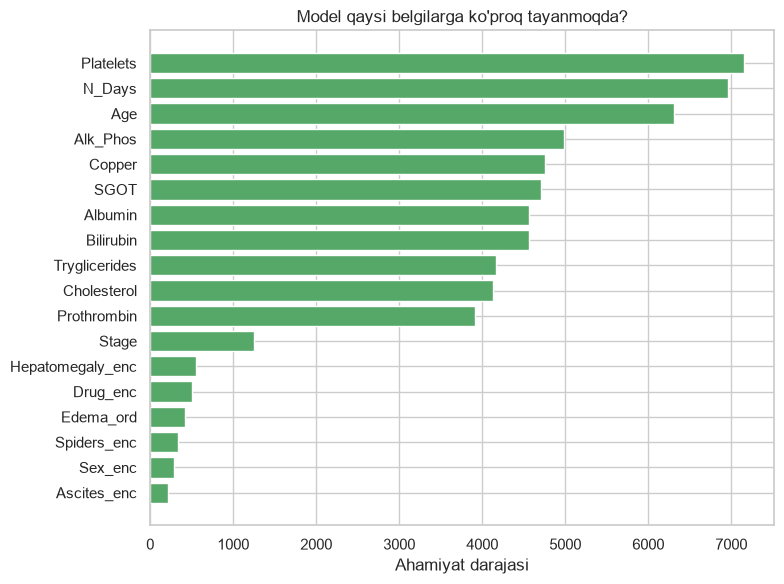

In [15]:
fi = pd.DataFrame({
    "feature": base_feature_cols,
    "importance": model.feature_importances_,
}).sort_values("importance", ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(fi["feature"][::-1], fi["importance"][::-1], color="#55A868")
ax.set_title("Model qaysi belgilarga ko'proq tayanmoqda?")
ax.set_xlabel("Ahamiyat darajasi")
plt.tight_layout()
plt.show()

`N_Days` (kuzatuv davomiyligi) eng yuqorida turibdi — bu mantiqan to'g'ri,
chunki bemor qancha uzoq kuzatilgan bo'lsa, uning holati haqida shuncha
ko'proq bilvosita ma'lumot bor. Lekin **e'tibor bering** — u yagona hukmron
belgi emas! `Platelets` va `Age` deyarli bir xil darajada muhim, va bir
qancha klinik ko'rsatkich (`Bilirubin`, `Albumin`, `Copper`...) ham sezilarli
hissa qo'shadi. Bu ishonchli belgi — model bitta "yorliq"qa emas, ko'plab
haqiqiy tibbiy dalilga tayanib qaror qabul qilmoqda.

## Yakuniy xulosalar — bu loyihadan nima o'rgandik?

Biz bitta bashorat modelidan ko'proq narsani qurdik — biz **ma'lumotlar bilan
muloqot qilishni** o'rgandik. Quyida bu loyihaning eng muhim saboqlari, ular
istalgan kelajakdagi ma'lumotlar tahlili loyihasida sizga foyda beradi:

1. **Har doim ma'lumotni tanishdan boshlang, modeldan emas.** Anomal `"Y"`
   qiymatini yoki blok-holidagi bo'sh joylarni ko'rmasdan modelga o'tib
   ketganimizda, natijamiz ancha yomonroq bo'lardi.
2. **Bo'sh qiymatlar har doim ham "xato" emas — ular hikoya aytadi.** Bizning
   holatda ular "qaysi bemor to'liq tekshiruvdan o'tgan" degan yashirin
   ma'lumotni o'zida saqlagan.
3. **"Ko'proq feature — yaxshiroq model" degani emas.** `log1p`
   transformatsiyasi bizga yordam berish o'rniga yomonlashtirdi, chunki
   daraxt-asosidagi modellar uchun bu ortiqcha shovqin edi. Har bir yangi
   g'oyani albatta **o'lchab** tekshiring.
4. **To'g'ri baholash usuli — muvaffaqiyatning yarmi.** Agar
   Cross-Validation'ni to'g'ri qurmaganimizda (masalan, "asl" bemorlarni
   tekshiruv bo'lagiga qo'yib yuborganimizda), o'zimizni aldab, aslida
   yomonroq bo'lgan modelni "yaxshi" deb hisoblashimiz mumkin edi.
5. **Sinf disbalansini har doim yodda tuting.** `CL` sinfi atigi ~2.5% bo'lgani
   uchun oddiy aniqlik mezoni chalg'ituvchi bo'lardi — shuning uchun log loss
   va Stratified CV kabi vositalar tanlandi.
6. **Yakuniy natija:** eng sodda "pol" modelimiz (~0.72 log loss) dan
   boshlab, to'g'ri tozalash, oqilona feature tanlovi va sozlangan LightGBM
   yordamida **~0.36 log loss**ga yetdik — bu yarmidan ko'proq yaxshilanish!

Muvaffaqiyat tilaymiz — ma'lumotlar bilan ishlash sizga ham xuddi shunday
qiziqarli bo'lsin! 🚀